In [162]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [163]:
df = pd.read_csv("C:/Users/Eduardo Filho/Desktop/projeto ICD/Trabalho-ICD-/Análise dos dados/dados_anuais_novo.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                1606 non-null   str    
 1   Especificação            1606 non-null   str    
 2   Porcentagens             1606 non-null   float64
 3   Incrementos/Decrementos  1606 non-null   float64
 4   Ano                      1606 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 62.9 KB


In [164]:
df.head(5)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
0,OS Version,Windows,96.86,0.94,2019
1,OS Version,Windows 10 64 bit,61.09,-2.68,2019
2,OS Version,Windows 7 64 bit,33.04,6.64,2019
3,OS Version,Windows 8.1 64 bit,1.79,-1.64,2019
4,OS Version,Windows 7,0.60,-0.92,2019


In [165]:
print(df[df["Especificação"].isnull()])

Empty DataFrame
Columns: [Categoria, Especificação, Porcentagens, Incrementos/Decrementos, Ano]
Index: []


In [166]:
a = df[df["Especificação"].isnull()]
print(f'Linhas faltantes: {len(a)}')
for i in range(len(a)):
    print(f" Categoria: {a["Categoria"].iloc[i]} Porcentagem: {a['Porcentagens'].iloc[i]}, ano: {a['Ano'].iloc[i]}")

Linhas faltantes: 0


In [167]:
df_memoria = df.copy()

In [168]:
df_memoria = df_memoria[df_memoria['Categoria'] == 'System RAM'].reset_index(drop=True)

In [169]:
df_memoria.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
0,System RAM,Less than 2 GB,0.10,-0.15,2019
1,System RAM,2 GB,0.63,-0.89,2019
2,System RAM,3 GB,1.96,-2.35,2019
3,System RAM,4 GB,6.00,-5.05,2019
4,System RAM,5 GB,0.31,-0.18,2019


In [170]:
df_memoria.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Ano
0,System RAM,Less than 2 GB,0.10,-0.15,2019
1,System RAM,2 GB,0.63,-0.89,2019
2,System RAM,3 GB,1.96,-2.35,2019
3,System RAM,4 GB,6.00,-5.05,2019
4,System RAM,5 GB,0.31,-0.18,2019


In [ ]:
tiers_ordem = ['4', '8', '16', '32', '64+', 'Mais de 16 GB (não classificado)', 'Outro (não classificado)']

# "Tabela de tradução": cada texto original vira uma faixa de RAM.
# Textos que não aparecem aqui (ex: '2 GB', 'Less than 2 GB') viram NaN.
mapa_tier = {
    '4 GB': '4',
    '8 GB': '8',
    '16 GB': '16',
    '32 GB': '32',
    '64 GB': '64+',
    'More than 64 GB': '64+',
    'More than 16 GB': 'Mais de 16 GB (não classificado)',
    'Other': 'Outro (não classificado)',
}

df_tiers = df[df['Categoria'] == 'System RAM'].copy()
df_tiers['Tier'] = df_tiers['Especificação'].map(mapa_tier)
df_tiers = df_tiers.dropna(subset=['Tier'])

# Agrupamento: soma a porcentagem de cada faixa de RAM, por ano
tier_pct = df_tiers.groupby(['Ano', 'Tier'])['Porcentagens'].sum().reset_index()
tier_pct.head()

,Ano,Tier,Porcentagens
0,2019,16,46.37
1,2019,4,6.00
2,2019,8,30.69
3,2019,Mais de 16 GB (não classificado),5.08
4,2020,16,49.95


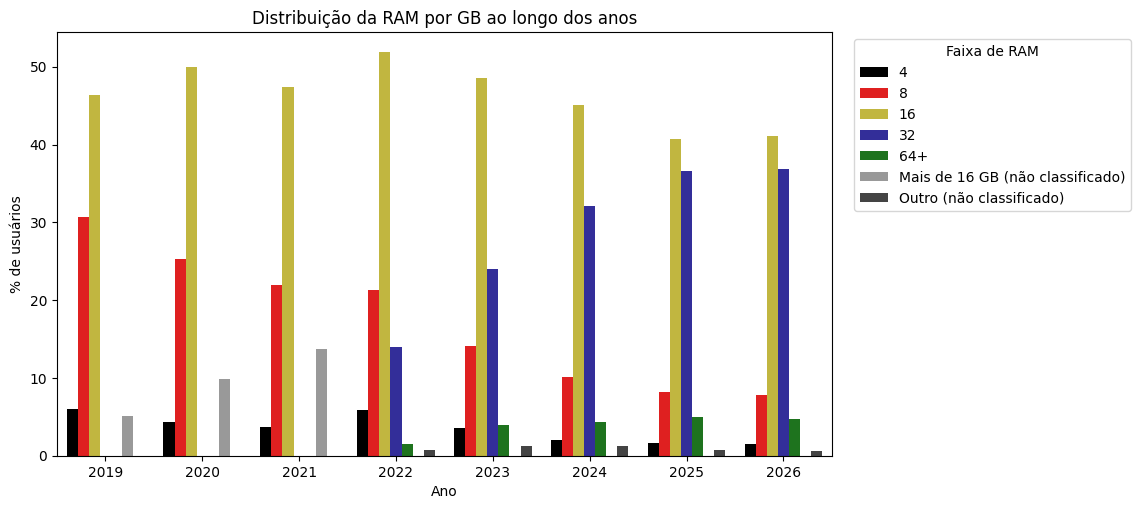

In [ ]:
# Só a paleta de cores muda em relação ao padrão do seaborn
cores = {
    '4': '#000000',
    '8': '#FF0000',
    '16': "#d6c82a",
    '32': "#231cab",
    '64+': "#108110",
    'Mais de 16 GB (não classificado)': '#999999',
    'Outro (não classificado)': '#444444',
}

plt.figure(figsize=(10, 5.5))

ax = sns.barplot(
    data=tier_pct,
    x='Ano',
    y='Porcentagens',
    hue='Tier',
    hue_order=tiers_ordem,
    palette=cores
)

plt.title('Distribuição da RAM por GB, ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('% de usuários')
plt.legend(title='Faixa de RAM', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()